# Сравнение attention-слоёв 

В этой работе будут сравнены следующие модели:
* `deit_tiny_pla_1d_v6_6` из статьи (линейное внимание за линейное время)
* `deit_small_linear` (линейное внимание)
* `deit_small` (квадратичное внимание)
Узрев результаты их обучения на cifar-10 поймем, даёт ли выхлоп обозреваемый в статье `deit_tiny_pla_1d_v6_6`

(Запуск приведенных shell-команд выполнялся вне ноутбука)

## Подготовка среды обучения

In [ ]:
!git clone git@github.com:DAGroup-PKU/MHLA.git && cd MHLA/mhla_image_classification

In [ ]:
!mkdir cifar10 && cd cifar10

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz && tar -xzf cifar-10-python.tar.gz

In [ ]:
!cd ..

In [ ]:
!uv pip install -r requirements.txt

## Обучение моделей

In [ ]:
!uv run python timm_train.py \
    --model deit_tiny_pla_1d_v6_6 \
    --data-dir ./cifar10 \
    --dataset torch/cifar10 \
    --opt adamw \
    --lr 1e-3 \
    --weight-decay 0.05 \
    --epochs 200 \
    --batch-size 64 \
    --grad-checkpointing \
    --sched cosine \
    --warmup-epochs 10 \
    --model-kwargs piece_size=4 transform=linear exp_sigma=1 \
    --gp avg \
    --experiment mhla_tiny

In [ ]:
!uv run python timm_train.py \
    --model deit_small_linear \
    --data-dir ./cifar10 \
    --dataset torch/cifar10 \
    --opt adamw \
    --lr 1e-3 \
    --weight-decay 0.05 \
    --epochs 200 \
    --batch-size 64 \
    --grad-checkpointing \
    --sched cosine \
    --warmup-epochs 10 \
    --gp avg \
    --amp \
    --mixup 0.2 \
    --cutmix 1.0 \
    --experiment deit_small_linear


In [ ]:
!uv run python timm_train.py \
    --model deit_small \
    --data-dir ./cifar10 \
    --dataset torch/cifar10 \
    --opt adamw \
    --lr 1e-3 \
    --weight-decay 0.05 \
    --epochs 200 \
    --batch-size 48 \
    --grad-checkpointing \
    --sched cosine \
    --warmup-epochs 10 \
    --gp avg \
    --amp \
    --mixup 0.2 \
    --cutmix 1.0 \
    --experiment deit_small

## Анализ результатов обучения

В результате выполнения этих команд были логи обучения были записаны в файлы `output/train/<model_name>/summary.csv`. Визуализируем эти логи

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Union

def plot_models_logs(
    data: List[Union[str, pd.DataFrame]],
    model_names: List[str] = None,
    figsize: tuple = (12, 10),
    style: str = "whitegrid"
) -> None:
    """
    Построение совместных графиков метрик для нескольких моделей.
    Для train_loss и eval_loss используется общий масштаб вертикальной оси.
    """
    dfs = []
    for i, src in enumerate(data):
        if isinstance(src, str):
            df = pd.read_csv(src)
        elif isinstance(src, pd.DataFrame):
            df = src.copy()
        else:
            raise TypeError("Каждый элемент data должен быть строкой (путь) или pandas DataFrame")
        required = ['epoch', 'train_loss', 'eval_loss', 'eval_top1', 'eval_top5', 'lr']
        missing = [col for col in required if col not in df.columns]
        if missing:
            raise ValueError(f"В источнике {i} отсутствуют колонки: {missing}")
        dfs.append(df)

    if model_names is None:
        model_names = [f"Model_{i+1}" for i in range(len(dfs))]
    else:
        if len(model_names) != len(dfs):
            raise ValueError("Длина model_names должна совпадать с количеством моделей")

    metrics = ['train_loss', 'eval_loss', 'eval_top1', 'eval_top5', 'lr']
    titles = ['Train Loss', 'Eval Loss', 'Eval Top-1 (%)', 'Eval Top-5 (%)', 'Learning Rate']

    sns.set_style(style)
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()
    axes[-1].set_visible(False)

    # Сначала построим все линии (нужно знать диапазон для train_loss и eval_loss)
    # Для этого сохраним ссылки на оси и соберем все значения
    loss_min = float('inf')
    loss_max = float('-inf')

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx]
        for df, name in zip(dfs, model_names):
            df_sorted = df.sort_values('epoch')
            ax.plot(df_sorted['epoch'], df_sorted[metric], marker='o', linestyle='-', label=name)
            # Для train_loss и eval_loss собираем глобальные min/max
            if metric in ('train_loss', 'eval_loss'):
                loss_min = min(loss_min, df_sorted[metric].min())
                loss_max = max(loss_max, df_sorted[metric].max())
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Применяем общий масштаб для двух первых графиков (индексы 0 и 1)
    if loss_min != float('inf') and loss_max != float('-inf'):
        # Добавим небольшой отступ сверху и снизу
        padding = (loss_max - loss_min) * 0.05
        axes[0].set_ylim(loss_min - padding, loss_max + padding)
        axes[1].set_ylim(loss_min - padding, loss_max + padding)

    plt.tight_layout()
    plt.show()

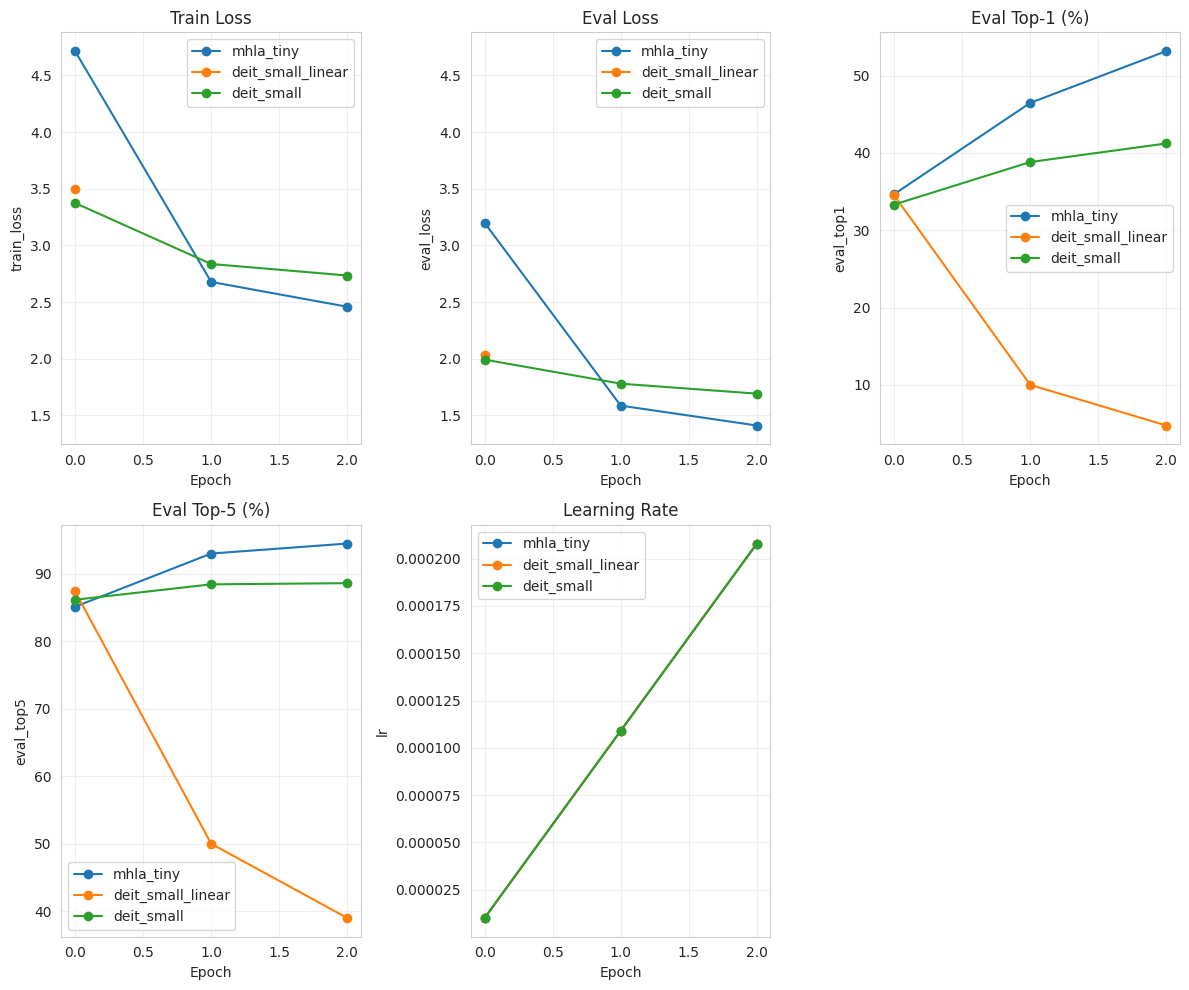

In [16]:
files = ["output/train/mhla_tiny/summary.csv", "output/train/deit_small_linear/summary.csv", "output/train/deit_small/summary.csv"]
plot_models_logs(files, model_names=list(map(lambda x : x.split('/')[2], files)))

Графики показывают, что `mhla_tiny` превосходит всех:
* loss снижается быстрее, чем квадратичного (линейное вышло в nan)
* accuracy (top-1 и top-5) растет быстрее квадратичного (линейное убывает)
Кроме того, при запуске было обнаружено, что `mhla_tiny` обучалась значительно быстрее своих соперников

# Итог

Данный эксперимент показывает, что модификация всего одной составляющей архитектуры модели может круто изменить качество её обучения.
Кроме того, для проведения экспериментов было крайне удобно пользоваться фреймворком timm. С ним для бенчмарка модели достаточно:
* Реализовать Transformer
* Зарегистрировать в timm
* Запустить shell-команду обучения
Причем первые два шага за меня выполнили MHLA.